In [1]:
#1. import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# 2. Load the Dataset
# The dataset is having the dependent variable (target) in the first column
data = pd.read_csv("MLR.csv")

In [3]:
# 3. Split Data into Features and Target
y = data.iloc[:, 0].values      # First column as target
X = data.iloc[:, 1:].values     # Remaining columns as features

# Add intercept term (bias) - column of ones
X = np.c_[np.ones(X.shape[0]), X]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (308, 7)
Shape of y: (308,)


In [4]:
# 4. Train-Test Split (80%-20%)
np.random.seed(42)  # for reproducibility
rows = X.shape[0]   # number of rows

rp = np.random.permutation(rows)

train_size = int(np.round(rows * 0.8))
train_idx, test_idx = rp[:train_size], rp[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 246
Testing samples: 62


In [5]:
# 5. Compute Regression Coefficients (Normal Equation)
# beta = (X^T X)^-1 X^T y
XtX = np.dot(X_train.T, X_train)
XtX_inv = np.linalg.inv(XtX)
XtX_inv_Xt = np.dot(XtX_inv, X_train.T)
beta = np.dot(XtX_inv_Xt, y_train)

print("Regression Coefficients (beta):\n", beta)


Regression Coefficients (beta):
 [ 2.77258477e-01 -3.68114951e+00 -1.20140370e+00  4.57901626e-01
  1.10171224e+00 -7.20828137e-01  2.76487696e-03]


In [6]:
# 6. Predict on Test Data
y_pred = np.dot(X_test, beta)

# Display few predictions
print(pd.DataFrame({'Actual': y_test[:10], 'Predicted': y_pred[:10]}))


   Actual  Predicted
0    -5.0  -2.370945
1    -2.3  -2.368008
2    -2.3  -2.247765
3    -2.3  -2.403073
4    -2.3  -2.442642
5    -5.0  -2.404028
6     0.0  -2.404392
7    -2.3  -2.389812
8    -2.3  -2.401589
9     0.0  -2.464460


In [7]:
# 7. Evaluate Model Performance (RMSE)
rss = np.sum((y_test - y_pred) ** 2)
rmse = np.sqrt(rss / len(y_test))

print(f"Root Mean Square Error (RMSE): {rmse:.4f}")


Root Mean Square Error (RMSE): 1.4583


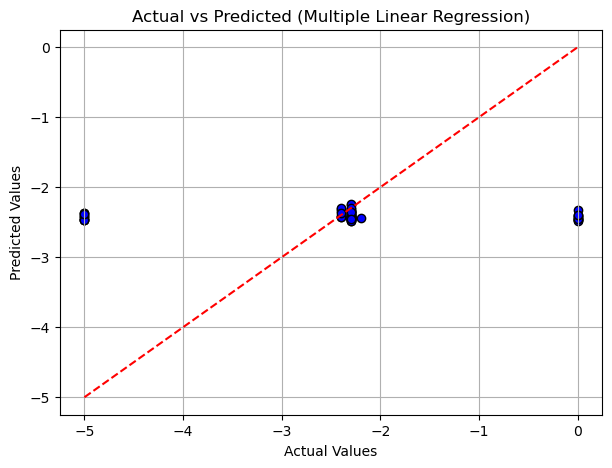

In [8]:
# 8. Visualization of Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='blue', edgecolors='black')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Multiple Linear Regression)")
plt.grid(True)
plt.show()

In [9]:
# 9. Optional: Feature Importance
coef_table = pd.DataFrame({
    'Feature': ['Intercept'] + list(data.columns[1:]),
    'Coefficient': beta
})

print(coef_table)

                                             Feature  Coefficient
0                                          Intercept     0.277258
1                              Prismatic coefficient    -3.681150
2                          Length-displacement ratio    -1.201404
3                                 Beam-draught ratio     0.457902
4                                  Length-beam ratio     1.101712
5                                      Froude number    -0.720828
6  Residuary resistance per unit weight of displa...     0.002765
